# LF Augmentation Workflow

This notebook expands the LF side by using the per-signal CNP export to synthesize additional LF trials. The HF rows stay fixed. The outputs are augmented CNP-style CSVs that can be passed directly into MF-GP.


In [1]:
from __future__ import annotations

import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display


def find_repo_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "prepare_resum_data.py").exists() and (candidate / "README.md").exists():
            return candidate
    raise RuntimeError("Could not find the XLZD repo root.")


REPO_ROOT = find_repo_root()
os.chdir(REPO_ROOT)
EXPERIMENT_DIR = REPO_ROOT / "lf_augmentations"
if str(EXPERIMENT_DIR) not in sys.path:
    sys.path.insert(0, str(EXPERIMENT_DIR))

from lf_augmentation import (
    augment_lf_trials_bootstrap,
    augment_lf_trials_merged,
    build_file_level_trials,
    default_paths,
    load_per_signal_predictions,
    load_training_cnp_csv,
    plot_tail_fraction_summary,
    plot_theta_mean_shift,
    plot_theta_trial_count_comparison,
    plot_trial_value_distributions,
    prepare_lf_augmentation_outputs,
    theta_support_summary,
    write_augmented_training_csv,
    write_mfgp_config_variant,
)

PATHS = default_paths()
N_AUGMENTED_TRIALS = 3
MERGE_SIZE = 4
RANDOM_STATE = 42
ARTIFACT_DIR = PATHS.artifact_dir

print(f"Repo root: {PATHS.repo_root}")
print(f"Config path: {PATHS.config_path}")
print(f"Per-signal CSV: {PATHS.per_signal_csv}")
print(f"Training CNP CSV: {PATHS.training_cnp_csv}")
print(f"Validation CNP CSV: {PATHS.validation_cnp_csv}")
print("LF augmentation mode: keep original LF + add synthetic LF")
print(f"Artifact dir: {ARTIFACT_DIR}")


Repo root: /home/klz/Data/XLZD/anpatnaik
Config path: /home/klz/Data/XLZD/anpatnaik/src/xlzd/settings_minibatch.yaml
Per-signal CSV: /home/klz/Data/XLZD/anpatnaik/data/out/cnp/cnp_xlzd_v1_minibatch_output_per_signal_15epochs.csv
Training CNP CSV: /home/klz/Data/XLZD/anpatnaik/data/out/cnp/cnp_xlzd_v1_minibatch_output_15epochs.csv
Validation CNP CSV: /home/klz/Data/XLZD/anpatnaik/data/out/cnp/cnp_xlzd_v1_minibatch_output_validation_15epochs.csv
LF augmentation mode: keep original LF + add synthetic LF
Artifact dir: /home/klz/Data/XLZD/anpatnaik/lf_augmentations/artifacts


## 1. Load The Existing LF/HF CNP Outputs


In [2]:
per_signal_df = load_per_signal_predictions(PATHS.per_signal_csv)
training_df = load_training_cnp_csv(PATHS.training_cnp_csv)
file_trials_df = build_file_level_trials(per_signal_df)
lf_trials_df = file_trials_df[file_trials_df["fidelity"].astype(int) == 0].copy()
hf_rows_df = training_df[training_df["fidelity"].astype(int) == 1].copy()

display(pd.DataFrame({
    "table": ["per_signal", "training_cnp", "lf_file_trials", "fixed_hf_rows"],
    "rows": [len(per_signal_df), len(training_df), len(lf_trials_df), len(hf_rows_df)],
}))
display(theta_support_summary(file_trials_df))


,table,rows
0,per_signal,3195349
1,training_cnp,127
2,lf_file_trials,106
3,fixed_hf_rows,21


,iteration,R_max,Z_max,theta_key,n_trials,total_events,mean_trial_size,mean_y_cnp,trial_y_cnp_std,mean_y_cnp_err
0,0,11.961295,397.09230,11.961295|397.092300,1,10049,10049.0,8.230013e-09,NaN,0.021824
1,0,33.177086,870.64636,33.177086|870.646360,1,10048,10048.0,9.481621e-08,NaN,0.018975
2,0,34.951480,1171.82280,34.951480|1171.822800,1,10048,10048.0,4.034213e-07,NaN,0.017633
3,0,56.701580,457.13930,56.701580|457.139300,1,10048,10048.0,1.022334e-08,NaN,0.021064
4,0,66.217120,925.74744,66.217120|925.747440,1,10049,10049.0,1.151297e-07,NaN,0.018431
...,...,...,...,...,...,...,...,...,...,...
101,0,1441.474100,1476.65000,1441.474100|1476.650000,1,10049,10049.0,8.168317e-02,NaN,0.009506
102,0,1443.955600,527.78700,1443.955600|527.787000,1,10048,10048.0,2.247775e-02,NaN,0.014872
103,0,1447.901000,1541.32730,1447.901000|1541.327300,1,10048,10048.0,8.852403e-02,NaN,0.009235
104,0,1453.552600,187.60025,1453.552600|187.600250,1,10049,10049.0,8.924310e-03,NaN,0.017404


## 2. Inspect The Original LF Trial Support


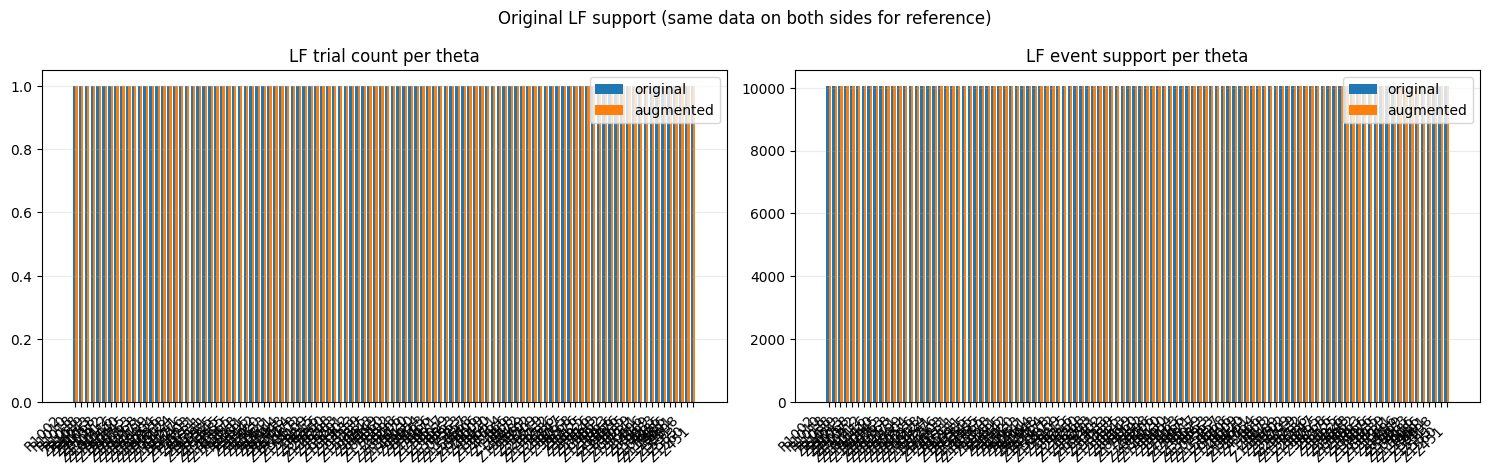

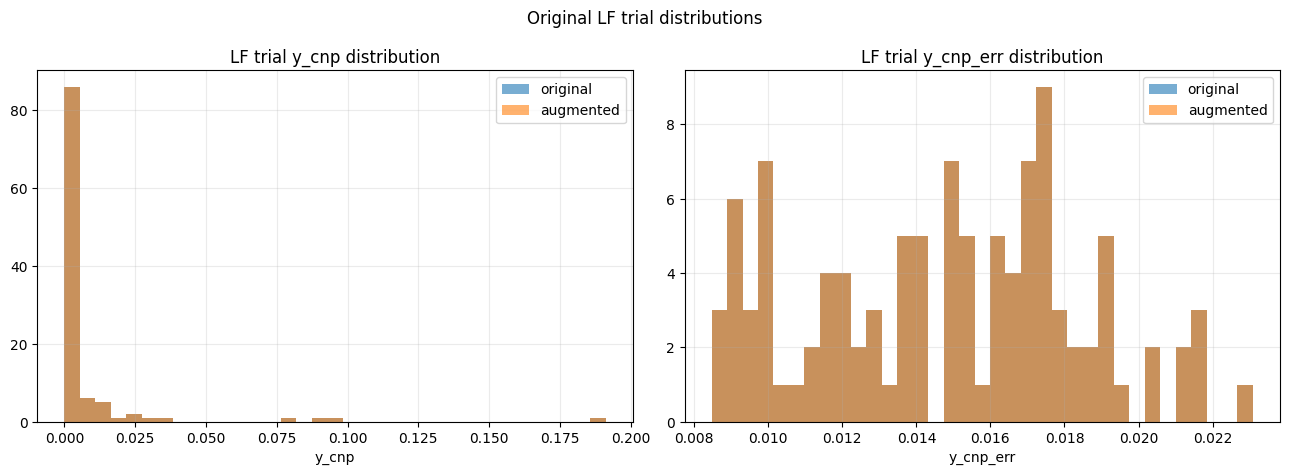

In [3]:
fig = plot_theta_trial_count_comparison(lf_trials_df, lf_trials_df, title="Original LF support (same data on both sides for reference)")
display(fig)
plt.close(fig)

fig = plot_trial_value_distributions(lf_trials_df, lf_trials_df, title="Original LF trial distributions")
display(fig)
plt.close(fig)


## 3. Build Augmented LF Trials


In [4]:
bootstrap_trials_df = augment_lf_trials_bootstrap(
    per_signal_df,
    n_augmented_trials=N_AUGMENTED_TRIALS,
    random_state=RANDOM_STATE,
)

merged_trials_df = augment_lf_trials_merged(
    file_trials_df,
    n_augmented_trials=N_AUGMENTED_TRIALS,
    merge_size=MERGE_SIZE,
    random_state=RANDOM_STATE,
)

display(pd.DataFrame({
    "dataset": ["original_lf", "bootstrap_lf_added", "merged_lf_added"],
    "rows": [len(lf_trials_df), len(bootstrap_trials_df), len(merged_trials_df)],
    "mean_y_cnp": [lf_trials_df["y_cnp"].mean(), bootstrap_trials_df["y_cnp"].mean(), merged_trials_df["y_cnp"].mean()],
    "mean_y_cnp_err": [lf_trials_df["y_cnp_err"].mean(), bootstrap_trials_df["y_cnp_err"].mean(), merged_trials_df["y_cnp_err"].mean()],
}))


,dataset,rows,mean_y_cnp,mean_y_cnp_err
0,original_lf,106,0.007014,0.014787
1,bootstrap_lf_added,318,0.007017,0.014785
2,merged_lf_added,318,0.007014,0.007393


## 4. Compare Bootstrap LF Augmentation Against The Original LF Trials


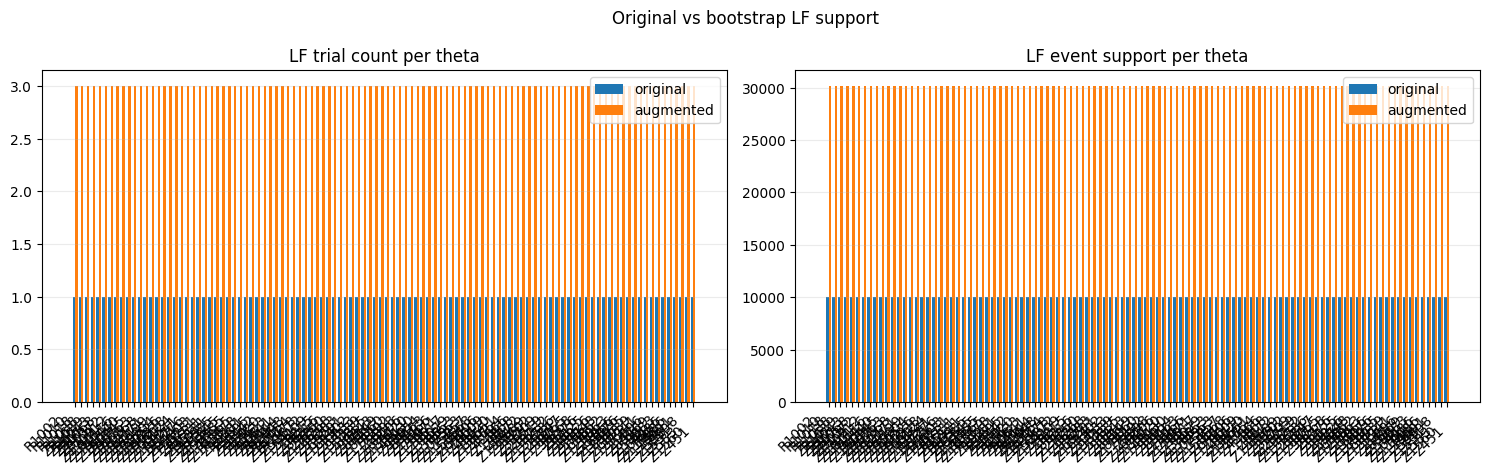

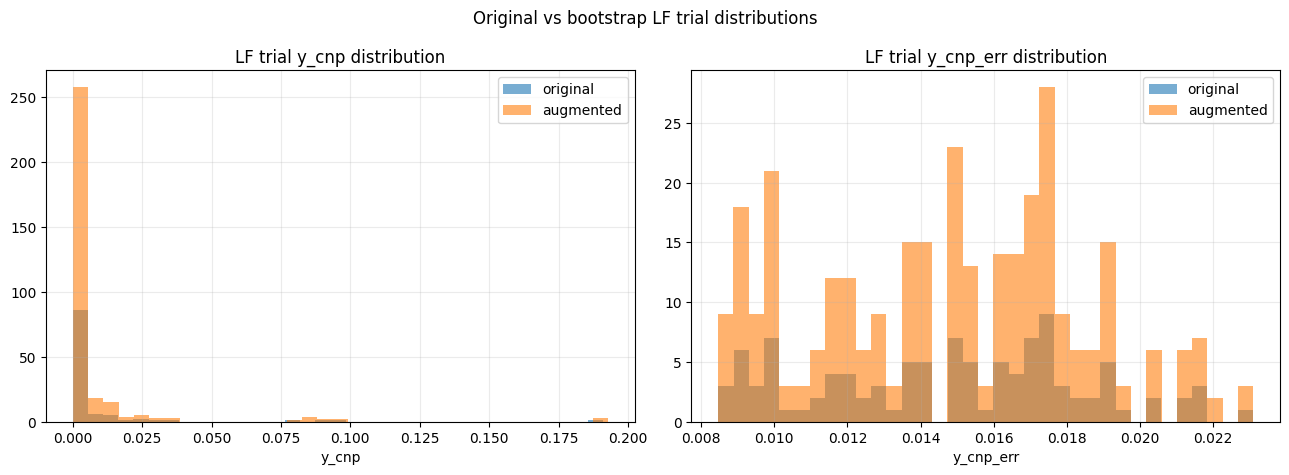

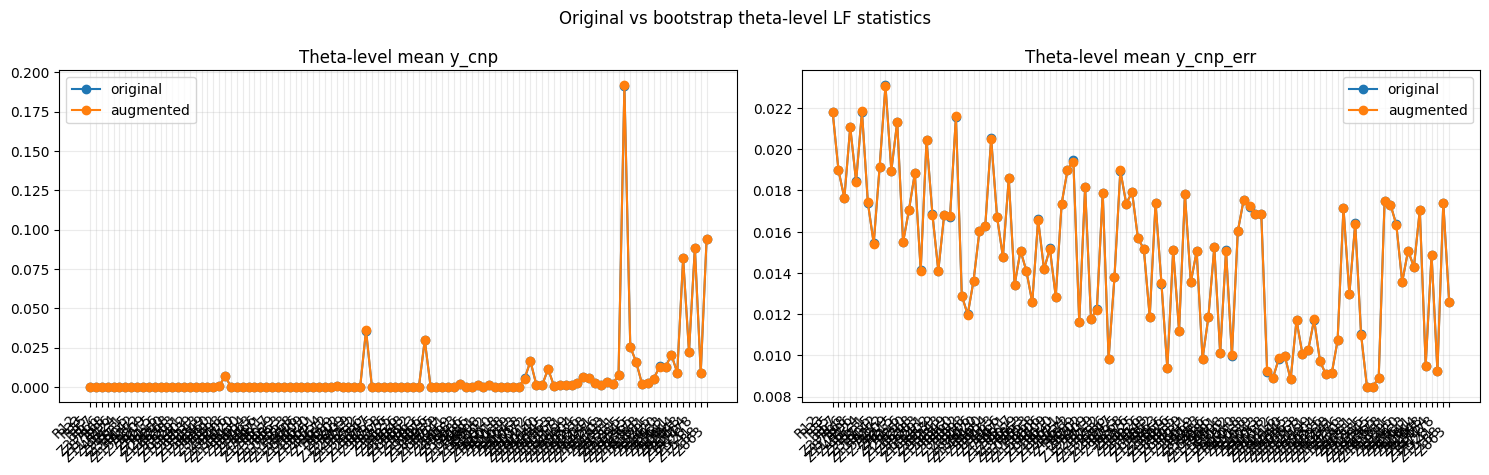

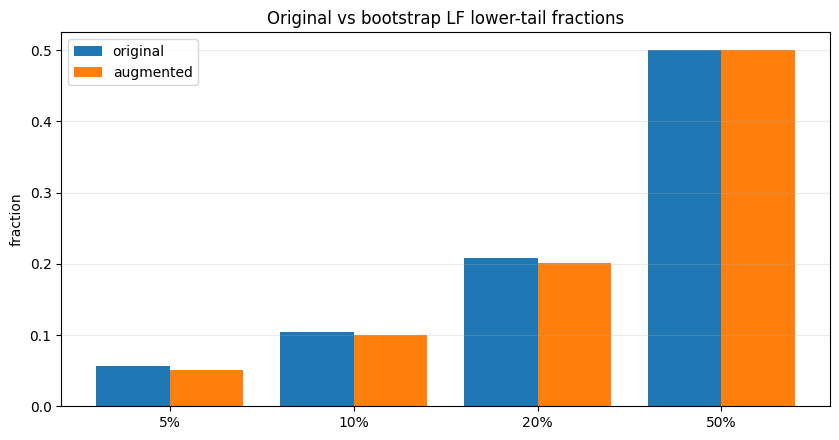

In [5]:
fig = plot_theta_trial_count_comparison(lf_trials_df, bootstrap_trials_df, title="Original vs bootstrap LF support")
display(fig)
plt.close(fig)

fig = plot_trial_value_distributions(lf_trials_df, bootstrap_trials_df, title="Original vs bootstrap LF trial distributions")
display(fig)
plt.close(fig)

fig = plot_theta_mean_shift(lf_trials_df, bootstrap_trials_df, title="Original vs bootstrap theta-level LF statistics")
display(fig)
plt.close(fig)

fig = plot_tail_fraction_summary(lf_trials_df, bootstrap_trials_df, title="Original vs bootstrap LF lower-tail fractions")
display(fig)
plt.close(fig)


## 5. Compare Merged-Block LF Augmentation Against The Original LF Trials


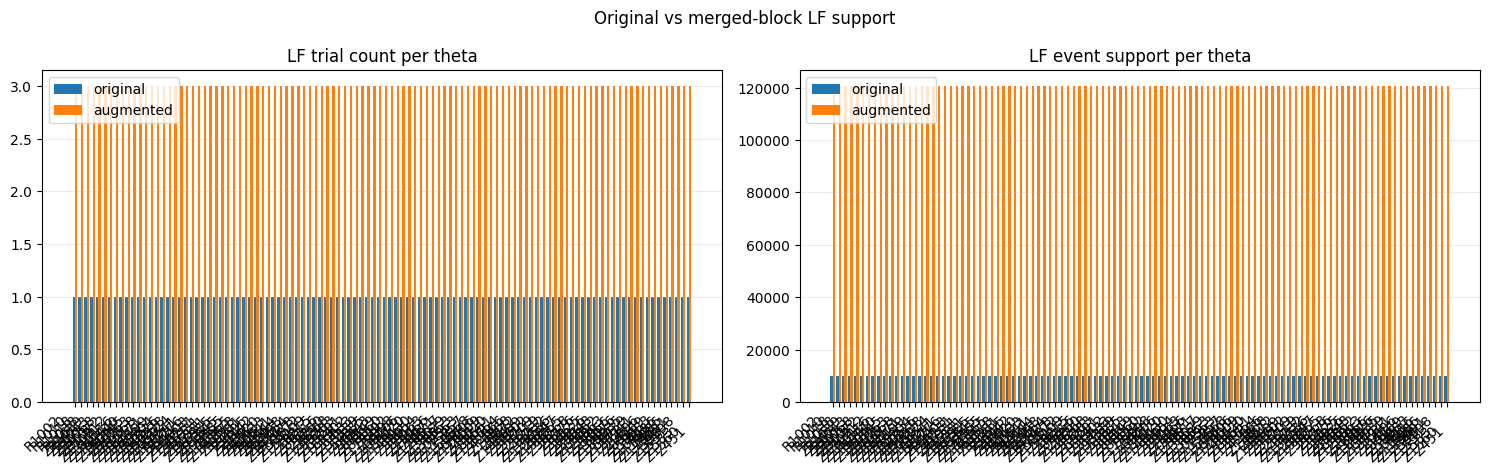

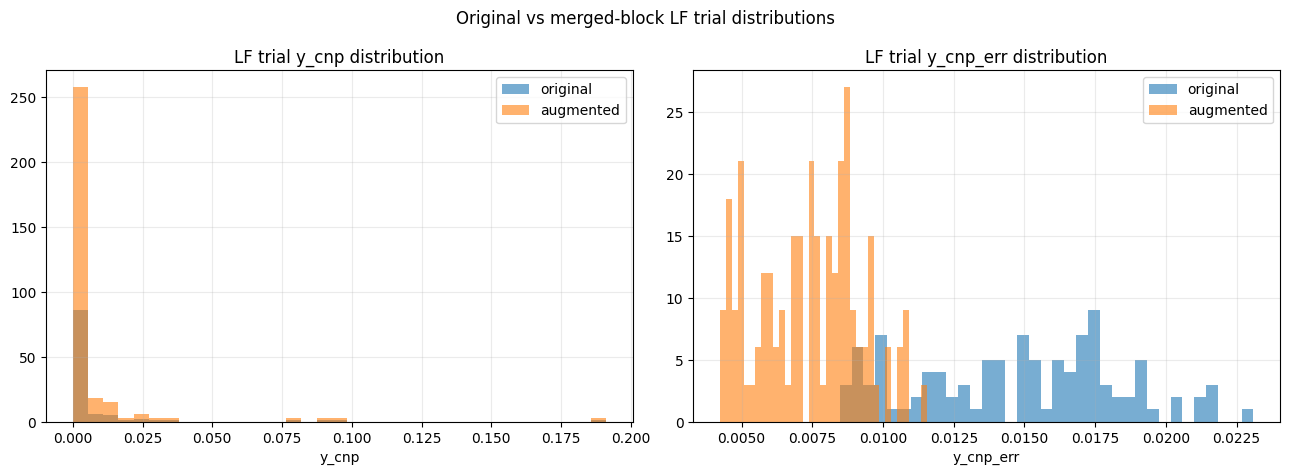

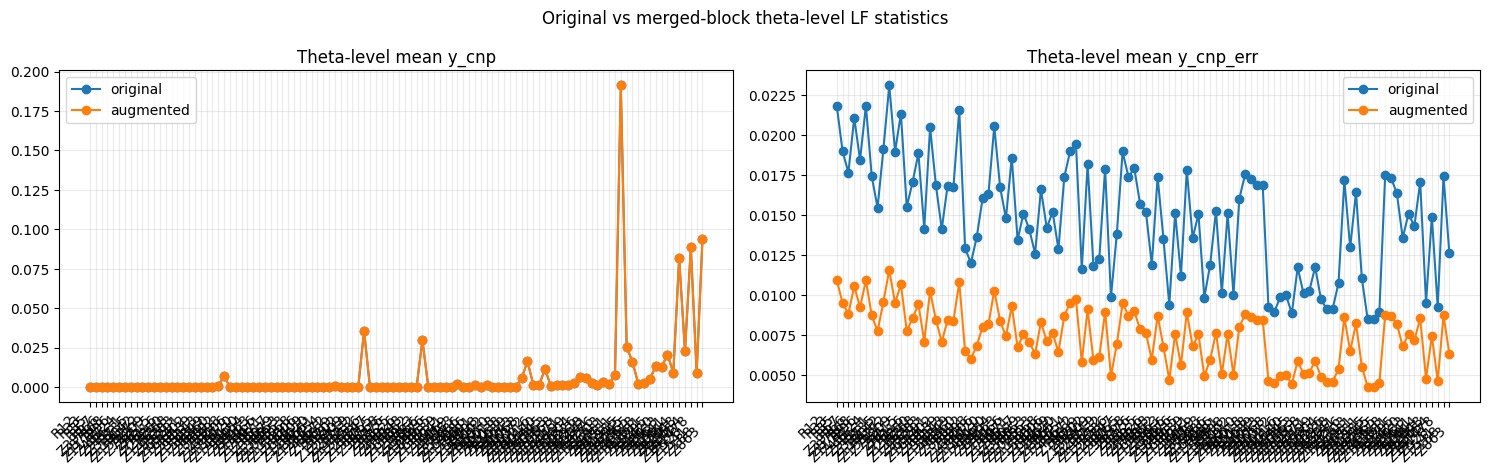

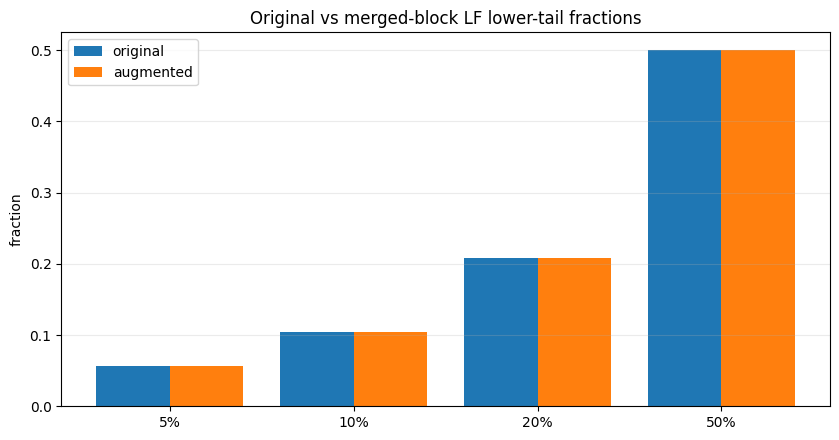

In [6]:
fig = plot_theta_trial_count_comparison(lf_trials_df, merged_trials_df, title="Original vs merged-block LF support")
display(fig)
plt.close(fig)

fig = plot_trial_value_distributions(lf_trials_df, merged_trials_df, title="Original vs merged-block LF trial distributions")
display(fig)
plt.close(fig)

fig = plot_theta_mean_shift(lf_trials_df, merged_trials_df, title="Original vs merged-block theta-level LF statistics")
display(fig)
plt.close(fig)

fig = plot_tail_fraction_summary(lf_trials_df, merged_trials_df, title="Original vs merged-block LF lower-tail fractions")
display(fig)
plt.close(fig)


## 6. Write Augmented CNP-Style CSVs And MF-GP Config Variants


In [7]:
bootstrap_training_csv = write_augmented_training_csv(
    ARTIFACT_DIR / "cnp_augmented_bootstrap_training.csv",
    training_df,
    bootstrap_trials_df,
    keep_original_lf=True,
)
merged_training_csv = write_augmented_training_csv(
    ARTIFACT_DIR / "cnp_augmented_merged_training.csv",
    training_df,
    merged_trials_df,
    keep_original_lf=True,
)

bootstrap_config = write_mfgp_config_variant(
    PATHS.config_path,
    output_path=ARTIFACT_DIR / "settings_bootstrap.yaml",
    version_suffix="lfbootstrap",
    out_dir_mfgp=ARTIFACT_DIR / "mfgp_bootstrap",
)
merged_config = write_mfgp_config_variant(
    PATHS.config_path,
    output_path=ARTIFACT_DIR / "settings_merged.yaml",
    version_suffix="lfmerged",
    out_dir_mfgp=ARTIFACT_DIR / "mfgp_merged",
)
baseline_config = write_mfgp_config_variant(
    PATHS.config_path,
    output_path=ARTIFACT_DIR / "settings_baseline.yaml",
    version_suffix="baseline",
    out_dir_mfgp=ARTIFACT_DIR / "mfgp_baseline",
)

artifact_df = pd.DataFrame({
    "artifact": [
        "bootstrap_training_csv",
        "merged_training_csv",
        "validation_cnp_csv",
        "baseline_config",
        "bootstrap_config",
        "merged_config",
    ],
    "path": [
        str(bootstrap_training_csv),
        str(merged_training_csv),
        str(PATHS.validation_cnp_csv),
        str(baseline_config),
        str(bootstrap_config),
        str(merged_config),
    ],
})
display(artifact_df)


,artifact,path
0,bootstrap_training_csv,/home/klz/Data/XLZD/anpatnaik/lf_augmentations...
1,merged_training_csv,/home/klz/Data/XLZD/anpatnaik/lf_augmentations...
2,validation_cnp_csv,/home/klz/Data/XLZD/anpatnaik/data/out/cnp/cnp...
3,baseline_config,/home/klz/Data/XLZD/anpatnaik/lf_augmentations...
4,bootstrap_config,/home/klz/Data/XLZD/anpatnaik/lf_augmentations...
5,merged_config,/home/klz/Data/XLZD/anpatnaik/lf_augmentations...
